In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Add project root to sys.path so "src" is importable
import sys
from pathlib import Path

root = Path.cwd()
while not (root / "src").exists() and root.parent != root:
    root = root.parent

sys.path.insert(0, str(root))

In [2]:
ml_df_path = root / "notebooks" / "lgbm_results_screening_complete.csv"
ml_df = pd.read_csv(ml_df_path)

for split in ["stratified", "disjoint_protein", "disjoint_aptamer"]:
    print(f"\n{split.upper()} - Top 3 (highest ROC-AUC mean):")
    top5 = ml_df[ml_df['split'] == split].nlargest(3, 'ROC-AUC mean')
    print(top5[['aptamer_encoder', 'protein_encoder', 'ROC-AUC mean', 'MCC mean']].to_string(index=False))


STRATIFIED - Top 3 (highest ROC-AUC mean):
aptamer_encoder protein_encoder  ROC-AUC mean  MCC mean
         OneHot            ESMC           1.0  0.999019
         OneHot         Prot_T5           1.0  0.998705
          Kmer3            ESMC           1.0  0.999019

DISJOINT_PROTEIN - Top 3 (highest ROC-AUC mean):
aptamer_encoder protein_encoder  ROC-AUC mean  MCC mean
       DNABERT2            ESMC      0.935910  0.561724
       DNABERT2            Ankh      0.928773  0.597626
          Kmer3            ESMC      0.918196  0.558151

DISJOINT_APTAMER - Top 3 (highest ROC-AUC mean):
aptamer_encoder protein_encoder  ROC-AUC mean  MCC mean
          Kmer3         Prot_T5      1.000000  0.993738
          Kmer4         Prot_T5      1.000000  0.991925
           GENA         Prot_T5      0.999999  0.992548


In [4]:
rn_df = pd.read_csv(root / "notebooks" / "notebooks" / "checkpoints_random" / "multimodel_results_screening_complete_random.csv")
ml_rn_df = pd.concat([ml_df, rn_df])
ml_rn_df.reset_index(drop=True)

,split,aptamer_encoder,protein_encoder,ROC-AUC mean,ROC-AUC std,MCC mean,MCC std,best_params,model
0,stratified,OneHot,ESMC,1.000000,7.021667e-17,0.999019,0.001324,"{'n_estimators': 714, 'learning_rate': 0.01224...",NaN
1,stratified,OneHot,Prot_T5,1.000000,0.000000e+00,0.998705,0.001587,"{'n_estimators': 425, 'learning_rate': 0.13125...",NaN
2,stratified,OneHot,Ankh,0.999990,1.282338e-05,0.995791,0.003761,"{'n_estimators': 425, 'learning_rate': 0.13125...",NaN
3,stratified,Kmer3,ESMC,1.000000,0.000000e+00,0.999019,0.001324,"{'n_estimators': 720, 'learning_rate': 0.05092...",NaN
4,stratified,Kmer3,Prot_T5,1.000000,0.000000e+00,0.998705,0.001587,"{'n_estimators': 685, 'learning_rate': 0.02281...",NaN
5,stratified,Kmer3,Ankh,0.999995,6.553328e-06,0.997110,0.003470,"{'n_estimators': 425, 'learning_rate': 0.13125...",NaN
6,stratified,Kmer4,ESMC,1.000000,0.000000e+00,0.999019,0.001324,"{'n_estimators': 720, 'learning_rate': 0.05092...",NaN
7,stratified,Kmer4,Prot_T5,1.000000,4.965068e-17,0.997460,0.003651,"{'n_estimators': 425, 'learning_rate': 0.13125...",NaN
8,stratified,Kmer4,Ankh,0.999999,1.930744e-06,0.996161,0.004679,"{'n_estimators': 425, 'learning_rate': 0.13125...",NaN
9,stratified,GENA,ESMC,1.000000,0.000000e+00,0.999019,0.001324,"{'n_estimators': 720, 'learning_rate': 0.05092...",NaN


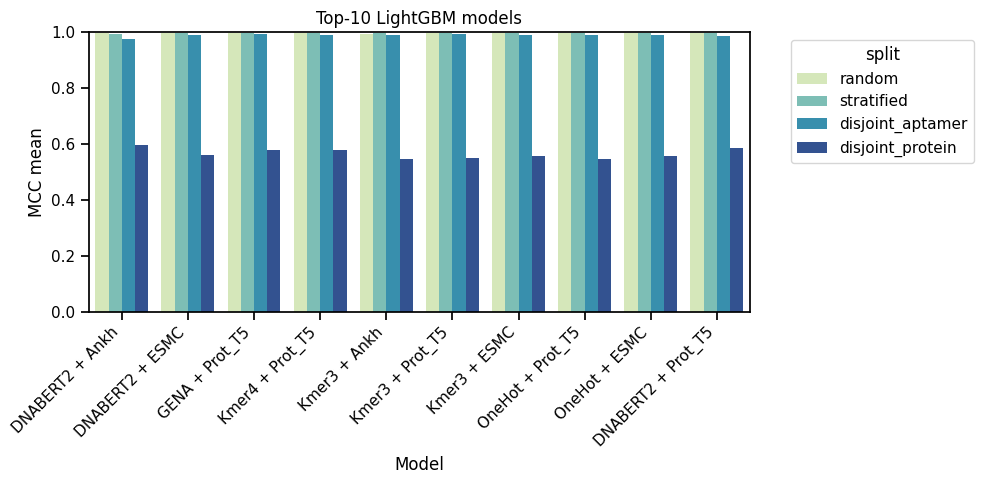

In [5]:
top_n = 10

best_disjoint_protein = (
    ml_rn_df[ml_rn_df["split"] == "disjoint_protein"]
    .groupby(["aptamer_encoder", "protein_encoder"])["MCC mean"]
    .mean()
    .reset_index()
    .sort_values("MCC mean", ascending=False)
    .head(top_n)
)

best_disjoint_protein



pair_df = ml_rn_df[
    ml_rn_df.set_index(["aptamer_encoder", "protein_encoder"]).index.isin(
        best_disjoint_protein.set_index(["aptamer_encoder", "protein_encoder"]).index
    )
].copy()


order = ["random", "stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split"] = pd.Categorical(pair_df["split"], categories=order, ordered=True)
pair_df = pair_df.sort_values("split")

pair_df["Model"] = (
    pair_df["aptamer_encoder"].astype(str)
    + " + "
    + pair_df["protein_encoder"].astype(str)
)


plt.figure(figsize=(10, 5))

sns.set_context("notebook")
sns.barplot(
    data=pair_df,
    x="Model",
    y="MCC mean",
    hue="split",
    palette="YlGnBu"
)

plt.legend(
    title="split",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title(f"Top-{top_n} LightGBM models")
plt.tight_layout()
plt.show()

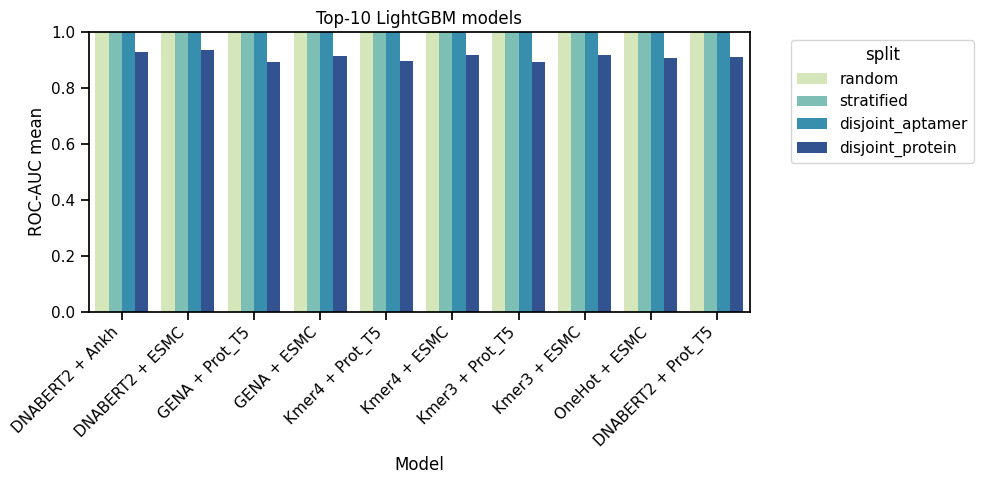

In [6]:
top_n = 10

best_disjoint_protein = (
    ml_rn_df[ml_rn_df["split"] == "disjoint_protein"]
    .groupby(["aptamer_encoder", "protein_encoder"])["ROC-AUC mean"]
    .mean()
    .reset_index()
    .sort_values("ROC-AUC mean", ascending=False)
    .head(top_n)
)

best_disjoint_protein



pair_df = ml_rn_df[
    ml_rn_df.set_index(["aptamer_encoder", "protein_encoder"]).index.isin(
        best_disjoint_protein.set_index(["aptamer_encoder", "protein_encoder"]).index
    )
].copy()





order = ["random", "stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split"] = pd.Categorical(pair_df["split"], categories=order, ordered=True)
pair_df = pair_df.sort_values("split")

pair_df["Model"] = (
    pair_df["aptamer_encoder"].astype(str)
    + " + "
    + pair_df["protein_encoder"].astype(str)
)


plt.figure(figsize=(10, 5))

sns.set_context("notebook")
sns.barplot(
    data=pair_df,
    x="Model",
    y="ROC-AUC mean",
    hue="split",
    palette="YlGnBu"
)

plt.legend(
    title="split",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title(f"Top-{top_n} LightGBM models")
plt.tight_layout()
plt.show()

In [3]:
df_1 = pd.read_csv(root / "artifacts" / "metrics" / "comprehensive_screening_disjoint_aptamer.csv")
df_2 = pd.read_csv(root / "artifacts" / "metrics" / "comprehensive_screening_disjoint_protein.csv")
df_3 = pd.read_csv(root / "artifacts" / "metrics" / "comprehensive_screening_stratified.csv")

dl_df = pd.concat([df_1, df_2, df_3])
dl_df.head()

,split_mode,model,apt_encoder,mol_encoder,config,ROC-AUC mean,ROC-AUC std,F1 mean,F1 std,MCC mean,MCC std,PR-AUC mean,PR-AUC std
0,disjoint_aptamer,TwoTowerMLP,OneHot,ESMC,TwoTowerMLP | OneHot + ESMC,0.999807,0.000386,0.997581,0.001246,0.995899,0.002175,0.999828,0.000345
1,disjoint_aptamer,TwoTowerMLP,OneHot,Prot_T5,TwoTowerMLP | OneHot + Prot_T5,0.999810,0.000233,0.994756,0.005958,0.990591,0.011449,0.999799,0.000246
2,disjoint_aptamer,TwoTowerMLP,OneHot,Ankh,TwoTowerMLP | OneHot + Ankh,0.994062,0.008883,0.967135,0.014478,0.947026,0.027161,0.990083,0.011068
3,disjoint_aptamer,TwoTowerMLP,GENA,ESMC,TwoTowerMLP | GENA + ESMC,0.999620,0.000732,0.996229,0.002519,0.993886,0.004506,0.999722,0.000504
4,disjoint_aptamer,TwoTowerMLP,GENA,Prot_T5,TwoTowerMLP | GENA + Prot_T5,0.999768,0.000385,0.996421,0.000978,0.994118,0.002010,0.999786,0.000337


In [7]:
best_df_MCC = (
    dl_df
    .sort_values('MCC mean', ascending=False)
    .drop_duplicates(subset=['split_mode', 'model'])
    .sort_values(['split_mode', 'model'])
    .reset_index(drop=True)
)

best_df_MCC[
    [
        'split_mode',
        'model',
        'apt_encoder',
        'mol_encoder',
        'F1 mean',
        'MCC mean',
        'ROC-AUC mean'
    ]
]

,split_mode,model,apt_encoder,mol_encoder,F1 mean,MCC mean,ROC-AUC mean
0,disjoint_aptamer,CrossAttention,OneHot,ESMC,0.998352,0.997012,0.999864
1,disjoint_aptamer,TwoTowerMLP,Kmer3,Prot_T5,0.998125,0.996901,0.999760
2,disjoint_aptamer,TwoTower_CNN_CNN,GENA,ESMC,0.997968,0.996818,0.999871
3,disjoint_aptamer,TwoTower_LSTM_LSTM,OneHot,ESMC,0.998899,0.997966,0.999708
4,disjoint_aptamer,TwoTower_Transformer_Transformer,DNABERT2,Prot_T5,0.996015,0.992988,0.998833
5,disjoint_protein,CrossAttention,OneHot,ESMC,0.710043,0.581620,0.863570
6,disjoint_protein,TwoTowerMLP,Kmer3,ESMC,0.765531,0.671081,0.874219
7,disjoint_protein,TwoTower_CNN_CNN,DNABERT2,Ankh,0.713911,0.591142,0.899595
8,disjoint_protein,TwoTower_LSTM_LSTM,Kmer3,Prot_T5,0.721332,0.617985,0.866340
9,disjoint_protein,TwoTower_Transformer_Transformer,DNABERT2,Prot_T5,0.672122,0.597913,0.891169


In [8]:
best_df = (
    dl_df.loc[
        dl_df.groupby(['split_mode', 'model'])['MCC mean'].idxmax()
    ]
)
best_df[['split_mode', 'model', 'apt_encoder', 'mol_encoder', 'F1 mean', 'MCC mean', 'ROC-AUC mean']]

,split_mode,model,apt_encoder,mol_encoder,F1 mean,MCC mean,ROC-AUC mean
9,disjoint_aptamer,CrossAttention,OneHot,ESMC,0.998352,0.997012,0.999864
9,disjoint_protein,CrossAttention,OneHot,ESMC,0.710043,0.581620,0.863570
9,stratified,CrossAttention,OneHot,ESMC,0.994409,0.990969,0.998634
46,disjoint_aptamer,TwoTowerMLP,Kmer3,Prot_T5,0.998125,0.996901,0.999760
46,disjoint_protein,TwoTowerMLP,Kmer3,Prot_T5,0.695949,0.615328,0.912164
46,stratified,TwoTowerMLP,Kmer3,Prot_T5,0.994786,0.991563,0.998481
21,disjoint_aptamer,TwoTower_CNN_CNN,GENA,ESMC,0.997968,0.996818,0.999871
21,disjoint_protein,TwoTower_CNN_CNN,GENA,ESMC,0.582242,0.460924,0.785216
21,stratified,TwoTower_CNN_CNN,GENA,ESMC,0.996271,0.993998,0.999358
27,disjoint_aptamer,TwoTower_LSTM_LSTM,OneHot,ESMC,0.998899,0.997966,0.999708


In [9]:
def clean_config(x):
    arch, enc = x.split("|")
    arch = arch.strip()
    enc = enc.strip()

    parts = arch.split("_")
    if len(parts) >= 2 and parts[-1] == parts[-2]:
        parts = parts[:-1]

    arch = "_".join(parts)

    return f"{arch}\n{enc}"

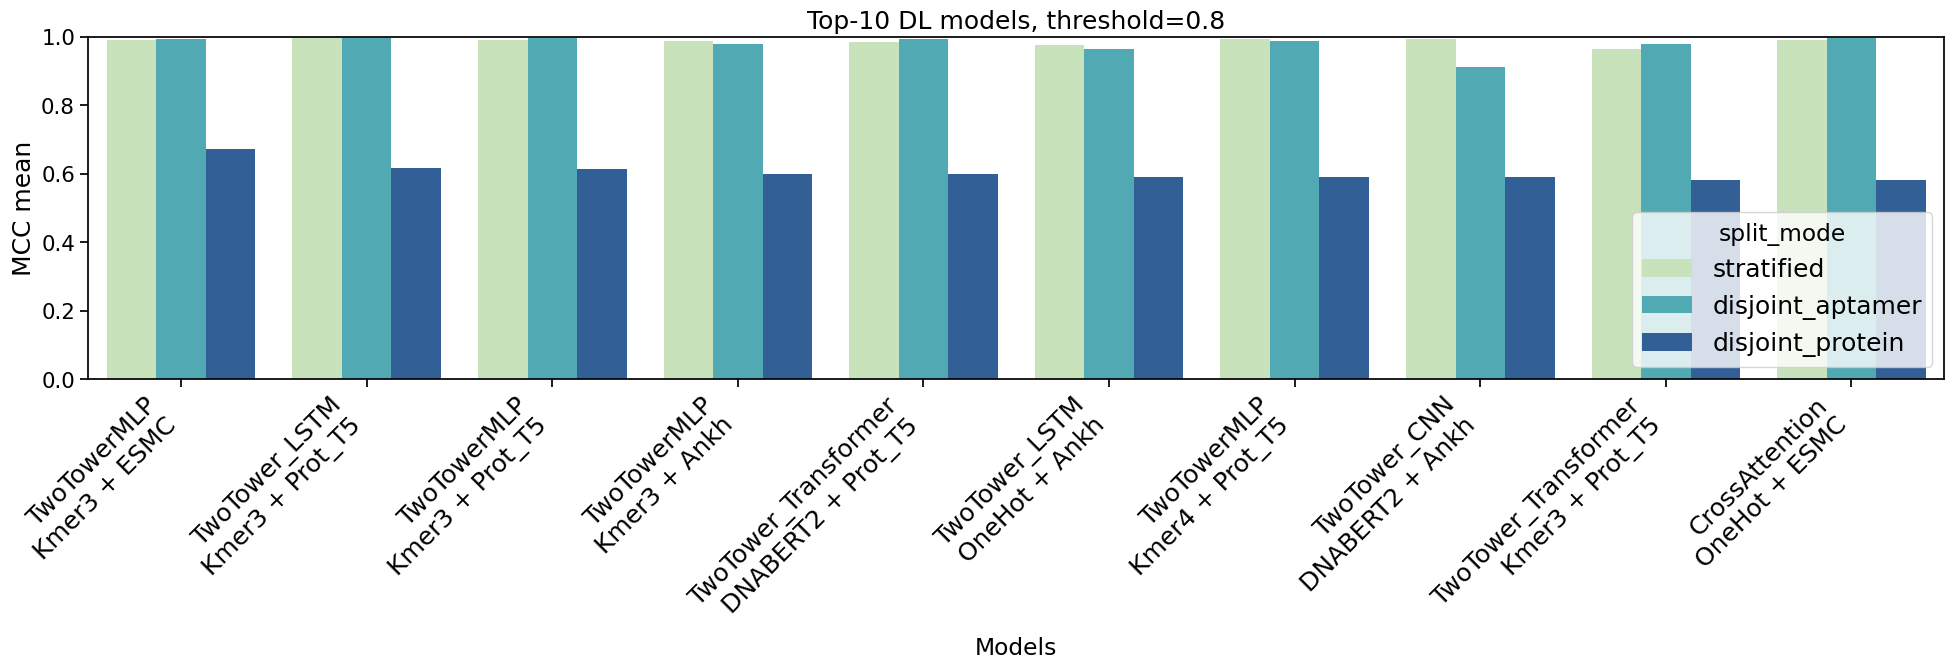

In [10]:
top_n = 10

best_disjoint_protein = (
    dl_df[dl_df["split_mode"] == "disjoint_protein"]
    .groupby("config")["MCC mean"]
    .mean()
    .reset_index()
    .sort_values("MCC mean", ascending=False)
    .head(top_n)
)


pair_df = dl_df[
    dl_df["config"].isin(best_disjoint_protein["config"])
].copy()

model_order = (
    best_disjoint_protein["config"]
    .apply(clean_config)
    .tolist()
)

order = ["stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split_mode"] = pd.Categorical(
    pair_df["split_mode"],
    categories=order,
    ordered=True
)

pair_df["Models"] = pair_df["config"].apply(clean_config)




sns.set_context("notebook", font_scale=1.4)
plt.figure(figsize=(20, 7))

sns.barplot(
    data=pair_df,
    x="Models",
    y="MCC mean",
    hue="split_mode",
    palette="YlGnBu",
    order=model_order,
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.legend(
    title="split_mode",
    loc="lower right",
    fontsize=18
)
plt.ylabel("MCC mean", fontsize=18)
plt.xticks(fontsize=18)
plt.title(f"Top-{top_n} DL models, threshold=0.8", fontsize=18)
plt.tight_layout()
plt.show()

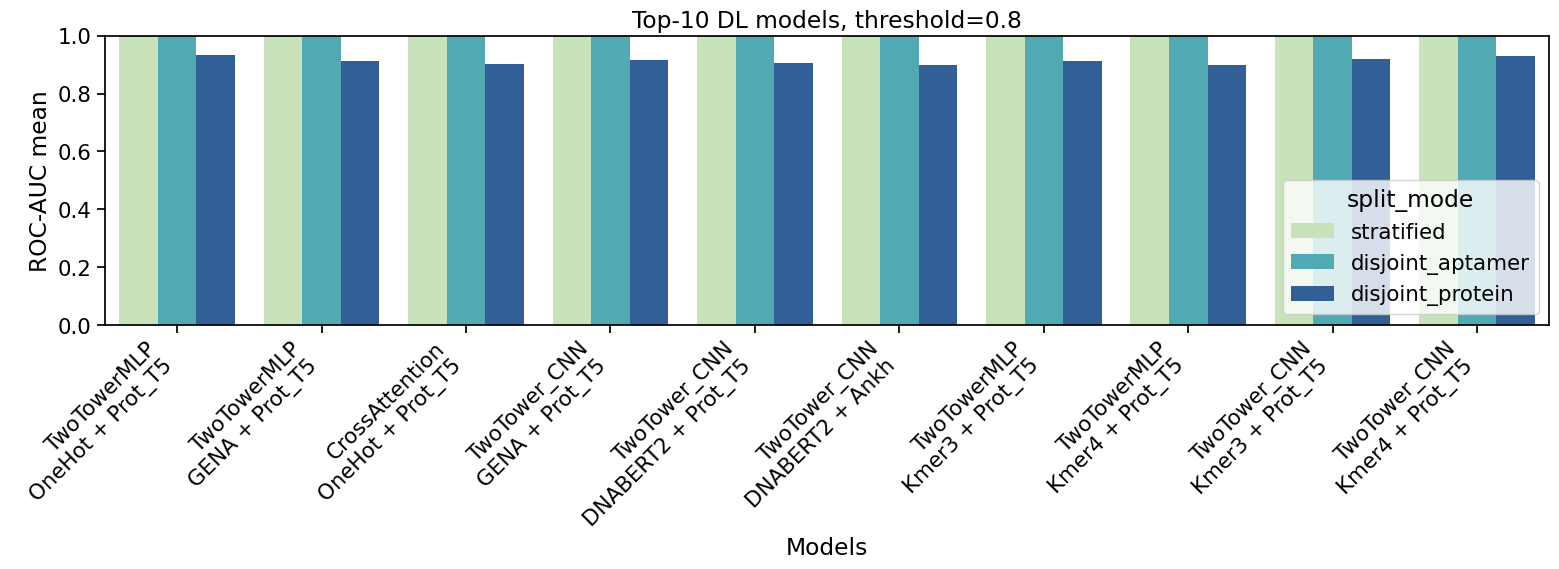

In [11]:
top_n = 10

best_disjoint_protein = (
    dl_df[dl_df["split_mode"] == "disjoint_protein"]
    .groupby("config")["ROC-AUC mean"]
    .mean()
    .reset_index()
    .sort_values("ROC-AUC mean", ascending=False)
    .head(top_n)
)


pair_df = dl_df[
    dl_df["config"].isin(best_disjoint_protein["config"])
].copy()



order = ["stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split_mode"] = pd.Categorical(
    pair_df["split_mode"],
    categories=order,
    ordered=True
)

pair_df["Models"] = pair_df["config"].apply(clean_config)



sns.set_context("notebook", font_scale=1.4)
plt.figure(figsize=(16, 6))

sns.barplot(
    data=pair_df,
    x="Models",
    y="ROC-AUC mean",
    hue="split_mode",
    palette="YlGnBu"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.legend(
    title="split_mode",
    loc="lower right"
)

plt.title(f"Top-{top_n} DL models, threshold=0.8")
plt.tight_layout()
plt.show()


# Only proteins

In [12]:
df_p = pd.read_csv(root / "notebooks" / "notebooks" / "checkpoints_proteins" / "multimodel_results_screening_complete.csv")
df_p.head()

,split,protein_encoder,ROC-AUC mean,ROC-AUC std,MCC mean,MCC std,best_params,model
0,stratified,ESMC,0.999998,0.000003,0.996994,0.004651,"{'n_estimators': 425, 'learning_rate': 0.13125...",lgbm
1,stratified,Prot_T5,0.998708,0.002585,0.996994,0.004651,"{'n_estimators': 283, 'learning_rate': 0.02205...",lgbm
2,stratified,Ankh,0.999581,0.000805,0.994585,0.005160,"{'n_estimators': 470, 'learning_rate': 0.07690...",lgbm
3,disjoint_protein,ESMC,0.891539,0.040841,0.592071,0.165627,"{'n_estimators': 414, 'learning_rate': 0.02139...",lgbm
4,disjoint_protein,Prot_T5,0.794346,0.220279,0.536163,0.287249,"{'n_estimators': 311, 'learning_rate': 0.13814...",lgbm


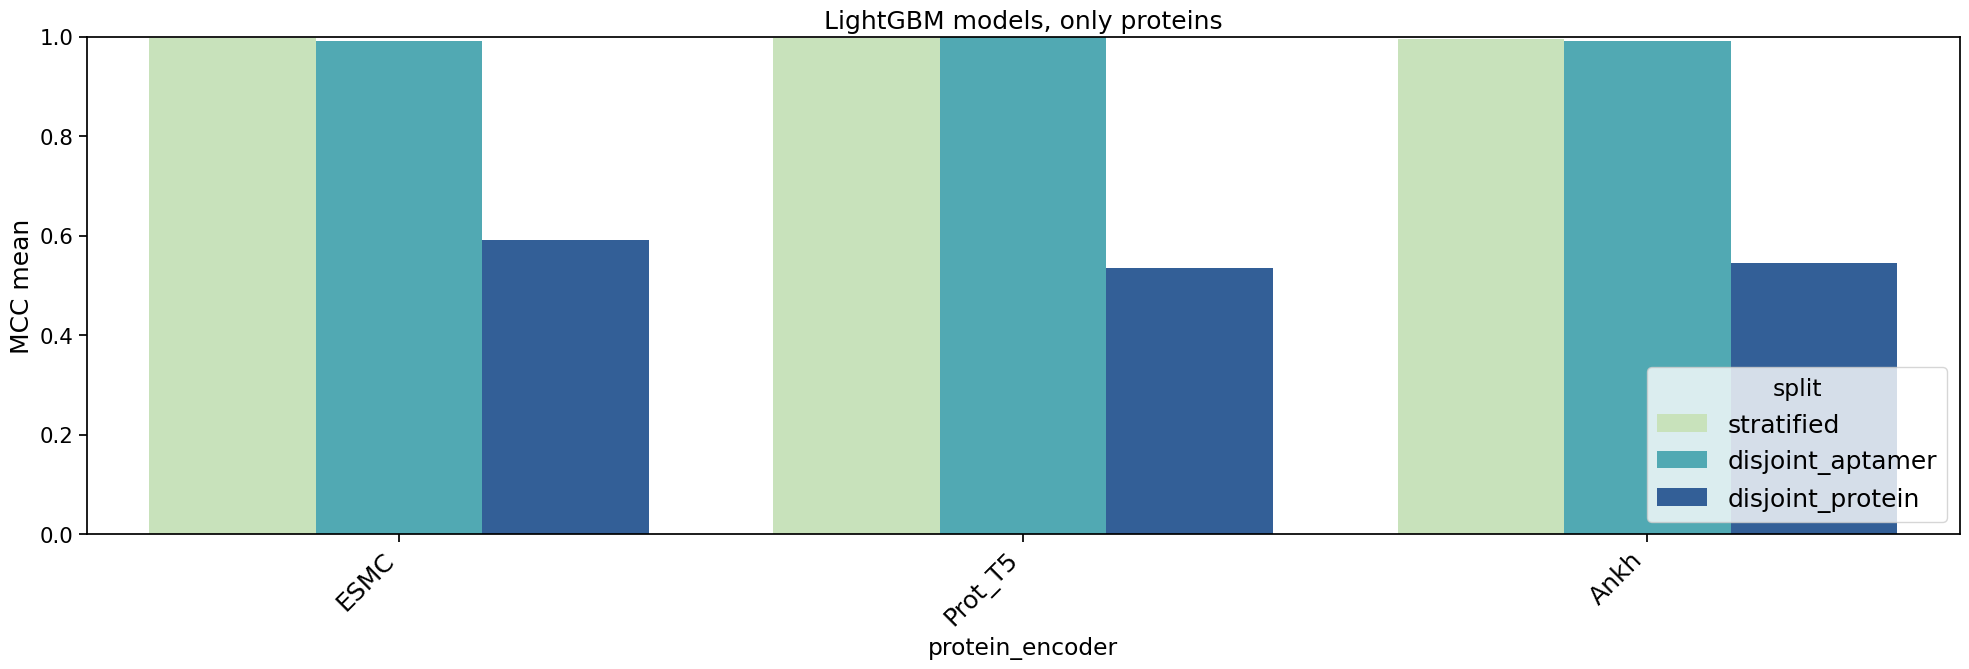

In [13]:
top_n = 10


best_stratified = (
    df_p[df_p["split"] == "disjoint_protein"]
    .groupby("protein_encoder")["MCC mean"]
    .mean()
    .reset_index()
    .sort_values("MCC mean", ascending=False)
    .head(top_n)
)


pair_df = df_p[
    df_p["protein_encoder"].isin(best_stratified["protein_encoder"])
].copy()



order = ["stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split"] = pd.Categorical(
    pair_df["split"],
    categories=order,
    ordered=True
)


sns.set_context("notebook", font_scale=1.4)
plt.figure(figsize=(20, 7))

sns.barplot(
    data=pair_df,
    x="protein_encoder",
    y="MCC mean",
    hue="split",
    palette="YlGnBu"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.legend(
    title="split",
    loc="lower right",
    fontsize=18
)
plt.ylabel("MCC mean", fontsize=18)
plt.xticks(fontsize=18)
plt.title(f"LightGBM models, only proteins", fontsize=18) #threshold
plt.tight_layout()
plt.show()

# Only aptamers

In [14]:
df_a = pd.read_csv(root / "notebooks" / "notebooks" / "checkpoints_aptamers" /"multimodel_results_screening_complete.csv")
df_a.head()

,split,aptamer_encoder,ROC-AUC mean,ROC-AUC std,MCC mean,MCC std,best_params,model
0,stratified,OneHot,0.935329,0.008452,0.728659,0.024916,"{'n_estimators': 283, 'learning_rate': 0.02205...",lgbm
1,stratified,Kmer3,0.936592,0.008890,0.741722,0.028624,"{'n_estimators': 283, 'learning_rate': 0.02205...",lgbm
2,stratified,Kmer4,0.936339,0.008090,0.741207,0.029046,"{'n_estimators': 283, 'learning_rate': 0.02205...",lgbm
3,stratified,GENA,0.954142,0.008958,0.787742,0.016615,"{'n_estimators': 685, 'learning_rate': 0.02281...",lgbm
4,stratified,DNABERT2,0.969576,0.003953,0.837095,0.010769,"{'n_estimators': 309, 'learning_rate': 0.01643...",lgbm


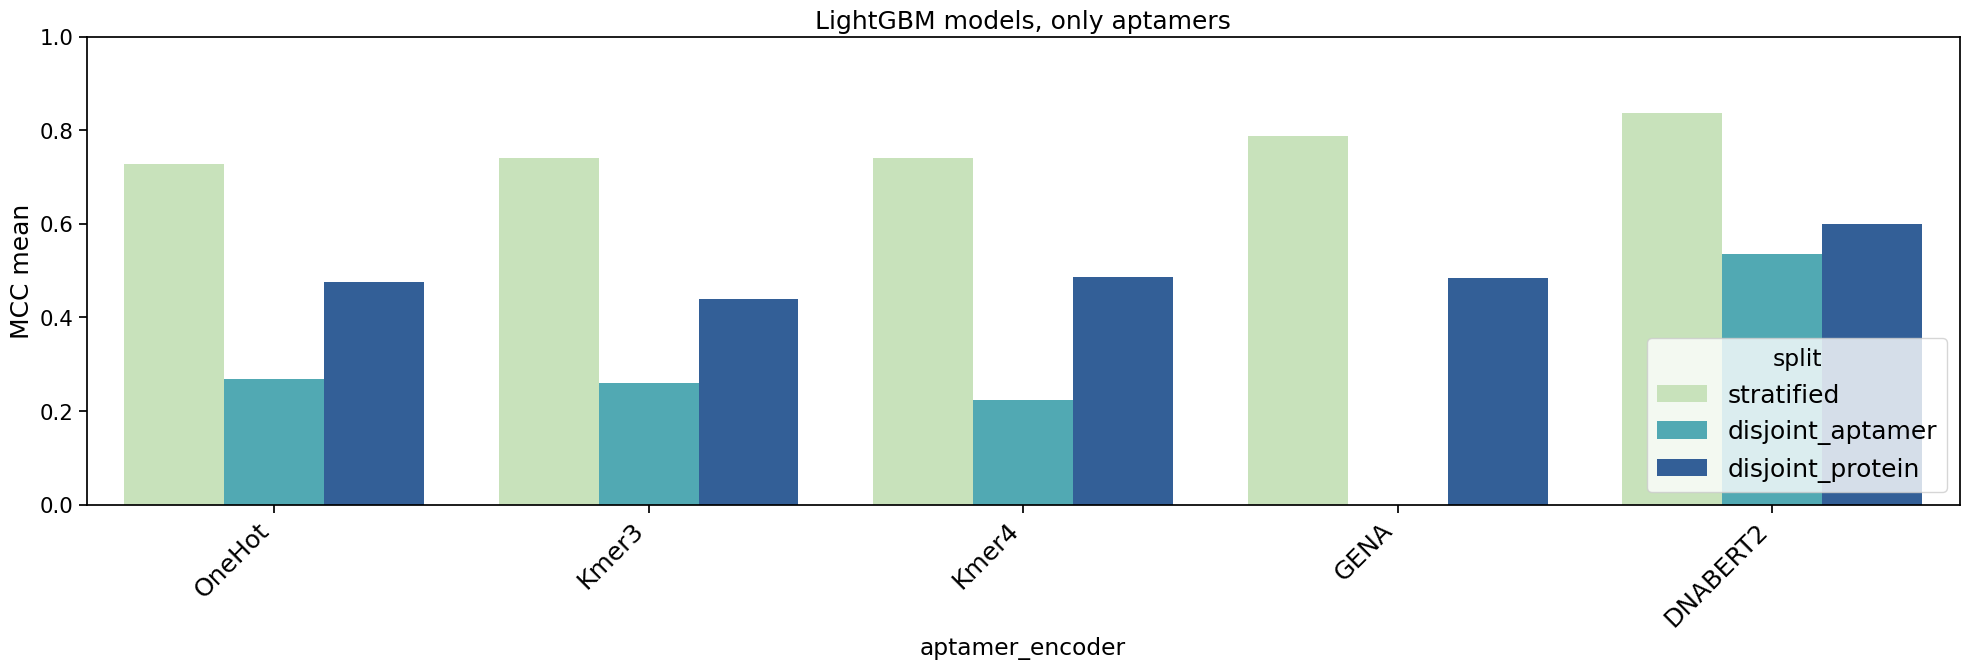

In [15]:
top_n = 10

best_stratified = (
    df_a[df_a["split"] == "disjoint_protein"]
    .groupby("aptamer_encoder")["MCC mean"]
    .mean()
    .reset_index()
    .sort_values("MCC mean", ascending=False)
    .head(top_n)
)


pair_df = df_a[
    df_a["aptamer_encoder"].isin(best_stratified["aptamer_encoder"])
].copy()


order = ["stratified", "disjoint_aptamer", "disjoint_protein"]

pair_df["split"] = pd.Categorical(
    pair_df["split"],
    categories=order,
    ordered=True
)


sns.set_context("notebook", font_scale=1.4)
plt.figure(figsize=(20, 7))

sns.barplot(
    data=pair_df,
    x="aptamer_encoder",
    y="MCC mean",
    hue="split",
    palette="YlGnBu"
)

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)

plt.legend(
    title="split",
    loc="lower right",
    fontsize=18
)
plt.ylabel("MCC mean", fontsize=18)
plt.xticks(fontsize=18)
plt.title(f"LightGBM models, only aptamers", fontsize=18)
plt.tight_layout()
plt.show()